## 1. Imports

In [1]:
import sys
sys.path.insert(0, "/Users/tiagoleite/Desktop/projeto_nlp")

In [39]:
import sys
import json
import os
import time
import numpy              as np
import pandas             as pd
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches

from pathlib                 import Path
from typing                  import Optional
from dotenv                  import load_dotenv
from openai                  import OpenAI 
from pydantic                import ValidationError
from sklearn.metrics         import (accuracy_score, classification_report, f1_score, precision_score, recall_score)
from sklearn.model_selection import train_test_split
from src.schema              import EditalClassificado


## 2. Funções

In [3]:
# Lê um arquivo de prompt da pasta /prompts e retorna o texto

def carregarPrompt(nome_arquivo: str) -> str:
    caminho = Path("..") / "prompts" / nome_arquivo
    return caminho.read_text(encoding="utf-8")

In [4]:
# Substitui o marcador {texto} no template pelo texto do edital

def montarPrompt(prompt_template: str, texto: str) -> str:
    return prompt_template.replace("{texto}", texto)

In [5]:
# Chama a API do Gemini com o texto do edital e o prompt informado
# Valida a resposta com o schema Pydantic EditalClassificado
 
# foram criados os seguintes fluxos:
#    - Tentativa 1: chamada normal com o prompt original
#    - Tentativa 2 (retry): chamada com instrução mais explícita se a
#      validação falhar
#    - Se ambas falharem: registra o erro e retorna None

# parâmetros da função:
#        texto           — texto limpo do edital
#        prompt_template — conteúdo do arquivo de prompt (zero-shot ou few-shot)
#        cliente         — instância autenticada do cliente Gemini
#        modelo          — nome do modelo a ser usado
# 
# o que a funçao vai retornar:
#   - EditalClassificado validado ou None em caso de falha

def classificarEdital(texto: str,
                      prompt_template: str,
                      cliente: OpenAI,
                      modelo: str,) -> Optional[EditalClassificado]:
 
    prompt_retry = (
        "<instrucao_adicional>\n"
        "Sua resposta anterior não estava no formato correto.\n"
        "Responda SOMENTE com JSON puro, sem texto antes ou depois, "
        "sem blocos de código, sem markdown, sem explicações.\n"
        "O JSON deve conter exatamente estes campos:\n"
        "categoria_objeto (string), modalidade (pregão|concorrência|dispensa|inexigibilidade), "
        "valor_estimado (número ou null), requisitos_habilitacao (lista de strings), "
        "alerta_risco (baixo|médio|alto), oportunidade_recomendada (true|false).\n"
        "</instrucao_adicional>\n\n"
    )
 
    for tentativa in range(1, 3):
        try:
            if tentativa == 1:
                prompt_final = montarPrompt(prompt_template, texto)
            else:
                prompt_final = prompt_retry + montarPrompt(prompt_template, texto)
 
            resposta = cliente.chat.completions.create(model=modelo, messages=[{"role": "user",
                                                                                "content": prompt_final}],
                                                                                temperature=0)
                                                                                #response_format={"type": "json_object"})

            texto_resposta = (resposta.choices[0].message.content.strip())
 
            # remove blocos de código se o modelo os incluir mesmo assim
            if texto_resposta.startswith("```"):
                linhas = texto_resposta.splitlines()
                linhas = [l for l in linhas if not l.startswith("```")]
                texto_resposta = "\n".join(linhas).strip()
 
            dados = json.loads(texto_resposta)
            resultado = EditalClassificado(**dados)
            return resultado
 
        except ValidationError as e:
            print(f"[tentativa {tentativa}] Erro de validação Pydantic: {e}")
            if tentativa == 2:
                print("[falha] Duas tentativas sem sucesso. Retornando None.")
                return None
 
        except json.JSONDecodeError as e:
            print(f"[tentativa {tentativa}] JSON inválido retornado pelo modelo: {e}")
            if tentativa == 2:
                print("[falha] Duas tentativas sem sucesso. Retornando None.")
                return None
 
        except Exception as e:
            print(f"[tentativa {tentativa}] Erro inesperado: {e}")
            if tentativa == 2:
                print("[falha] Duas tentativas sem sucesso. Retornando None.")
                return None
 
        time.sleep(1.5)
 
    return None

In [6]:
# a funçao roda classificarEdital em um lote de editais.
 
# os parâmetros:
#    df_amostra      — DataFrame com os editais a classificar
#    prompt_template — template do prompt (zero-shot ou few-shot)
#    cliente         — instância autenticada do cliente Gemini
#    modelo          — nome do modelo a ser usado
#    intervalo       — tempo de espera entre chamadas (em segundos)
 
# a funçao vai retornar:
#    Uma lista de dicionários com os resultados (ou None para falhas)
 

def classificarLote(df_amostra: pd.DataFrame,
                    prompt_template: str,
                    cliente: OpenAI,
                    modelo: str,
                    intervalo: float = 1.5) -> list:
    
    resultados = []
 
    for i, (idx, row) in enumerate(df_amostra.iterrows()):
        print(f"[{i+1}/{len(df_amostra)}] Classificando edital índice {idx}...")
 
        resultado = classificarEdital(
            texto=row["objetoCompra"],
            prompt_template=prompt_template,
            cliente=cliente,
            modelo=modelo,
        )
 
        if resultado:
            entrada = resultado.model_dump()
            entrada["idx_original"] = idx
            entrada["categoria_real"] = row["categoria"]
            entrada['erro']= False 
            resultados.append(entrada)
        else:
            resultados.append({
                "idx_original": idx,
                "categoria_real": row["categoria"],
                "modalidade": None,
                "erro": True,
            })
 
        time.sleep(intervalo)
 
    return resultados

In [7]:
# Converte o valor de modalidade do schema para o formato usado nas classes reais do dataset, para comparação com o baseline.
 
def mapearModalidade(modalidade: Optional[str]) -> Optional[str]:
    
    mapa = {
        "pregão": "Pregão - Eletrônico",
        "concorrência": "Concorrência - Eletrônica",
        "dispensa": "Dispensa de Licitação",
        "inexigibilidade": "Inexigibilidade",
    }
    if modalidade is None:
        return None
    return mapa.get(modalidade.lower(), None)

In [8]:
# Calcula F1 macro, precision, recall e accuracy para um conjunto de previsões.

def calcularMetricas(y_real: list, y_pred: list, nome_modelo: str) -> dict:

    return {
        "Modelo": nome_modelo,
        "F1 Macro": round(f1_score(y_real, y_pred, average="macro", zero_division=0), 4),
        "Precision": round(precision_score(y_real, y_pred, average="macro", zero_division=0), 4),
        "Recall": round(recall_score(y_real, y_pred, average="macro", zero_division=0), 4),
        "Accuracy": round(accuracy_score(y_real, y_pred), 4)}

In [9]:
#  Extrai os contadores de tokens da resposta da API do Gemini

def contarTokens(resposta):

    return {"tokens_entrada": resposta.usage.prompt_tokens,
            "tokens_saida": resposta.usage.completion_tokens,
            "tokens_total": resposta.usage.total_tokens}

In [10]:
#Projeta o custo de processar n_editais com base na média de tokens coletada da API

def estimarCusto(media_entrada: float,
                 media_saida: float,
                 n_editais: int,
                 preco_entrada_por_milhao: float,
                 preco_saida_por_milhao: float,
                 nome_modelo: str) -> dict:
    
    total_entrada = media_entrada * n_editais
    total_saida = media_saida * n_editais
    custo_entrada = (total_entrada / 1_000_000) * preco_entrada_por_milhao
    custo_saida = (total_saida / 1_000_000) * preco_saida_por_milhao
    custo_total = custo_entrada + custo_saida
 
    return {
        "Modelo": nome_modelo,
        "Tokens entrada (média)": round(media_entrada, 1),
        "Tokens saída (média)": round(media_saida, 1),
        "Custo entrada USD": round(custo_entrada, 4),
        "Custo saída USD": round(custo_saida, 4),
        "Custo total USD": round(custo_total, 4),
        f"Custo total para {n_editais} editais (USD)": round(custo_total, 4),
    }

In [11]:
# Extrai listas de labels reais e previstos a partir dos resultados do lote e remove os registros com erro (modalidade None)

def extrairPrevisoes(resultados: list) -> tuple:
   
    y_real, y_pred = [], []

    for r in resultados:
        if r.get("modalidade") is None:
            continue
        pred_mapeada = mapearModalidade(r["modalidade"])
        if pred_mapeada is None:
            continue
        y_real.append(r["categoria_real"])
        y_pred.append(pred_mapeada)
        
    return y_real, y_pred

## 3. Cofiguração LLM

In [12]:
# Groq

load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

if not GROQ_API_KEY:
    raise ValueError(
        "Chave GROQ_API_KEY não encontrada no .env")

cliente = OpenAI( api_key=GROQ_API_KEY,
                  base_url="https://api.groq.com/openai/v1")

MODELO_PRINCIPAL = "llama-3.3-70b-versatile"

print(f"Modelo principal: {MODELO_PRINCIPAL}")
print("Cliente Groq configurado com sucesso.")

Modelo principal: llama-3.3-70b-versatile
Cliente Groq configurado com sucesso.


In [13]:
# Gemini
#load_dotenv()
# 
#GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
# 
#if not GEMINI_API_KEY:
#    raise ValueError("Chave GEMINI_API_KEY não encontrada no arquivo .env")
# 
#cliente = genai.Client(api_key=GEMINI_API_KEY)
# 
#MODELO_PRINCIPAL = "gemini-2.5-flash-lite"
# 
#print(f"Modelo principal: {MODELO_PRINCIPAL}")
#print("Cliente Gemini configurado com sucesso.")

## 4. Carga dos Dados

In [13]:
CAMINHO_PARQUET = Path("../dados/processed/editais_processado.parquet")
 
df = pd.read_parquet(CAMINHO_PARQUET)
 
print(f"Total de editais carregados: {len(df)}")
print(f"\nDistribuição por categoria:")
print(df["categoria"].value_counts())
print(f"\nColunas disponíveis: {df.columns.tolist()}")

Total de editais carregados: 3009

Distribuição por categoria:
categoria
Pregão - Eletrônico          1899
Concorrência - Eletrônica    1060
Concorrência - Presencial      50
Name: count, dtype: int64

Colunas disponíveis: ['modalidadeId', 'modoDisputaId', 'srp', 'dataAtualizacao', 'dataInclusao', 'dataPublicacaoPncp', 'orgaoEntidade', 'anoCompra', 'sequencialCompra', 'numeroCompra', 'unidadeOrgao', 'amparoLegal', 'dataAberturaProposta', 'dataEncerramentoProposta', 'informacaoComplementar', 'processo', 'objetoCompra', 'linkSistemaOrigem', 'justificativaPresencial', 'unidadeSubRogada', 'orgaoSubRogado', 'valorTotalHomologado', 'linkProcessoEletronico', 'emendaParlamentar', 'dataAtualizacaoGlobal', 'numeroControlePNCP', 'valorTotalEstimado', 'modalidadeNome', 'modoDisputaNome', 'tipoInstrumentoConvocatorioCodigo', 'tipoInstrumentoConvocatorioNome', 'fontesOrcamentarias', 'situacaoCompraId', 'situacaoCompraNome', 'usuarioNome', 'modalidade_nome', 'categoria', 'texto_limpo']


## 5. Schema Pydantic

In [14]:
# Exibe os campos do schema para conferência

for nome, campo in EditalClassificado.model_fields.items():
    print(f"  {nome}: {campo.annotation}")
    if campo.description:
        print(f"    → {campo.description[:80]}...")
    print()

  categoria_objeto: <class 'str'>
    → Categoria do objeto licitado, descrita em linguagem simples. Exemplos: 'serviços...

  modalidade: typing.Literal['pregão', 'concorrência', 'dispensa', 'inexigibilidade']
    → Modalidade do processo licitatório. Usar 'pregão' para Pregão Eletrônico ou Pres...

  valor_estimado: typing.Optional[float]
    → Valor estimado do contrato em reais (R$), como número decimal. Extrair do texto ...

  requisitos_habilitacao: typing.List[str]
    → Lista de exigências para o fornecedor participar da licitação. Exemplos: 'certid...

  alerta_risco: typing.Literal['baixo', 'médio', 'alto']
    → Nível de risco do edital para um fornecedor participar. 'baixo': objeto simples,...

  oportunidade_recomendada: <class 'bool'>
    → Indica se o edital é uma boa oportunidade para participar. True se o objeto é co...



## 6. Carga dos Prompts

In [15]:
prompt_zero_shot = carregarPrompt("prompt_zero_shot.txt")
prompt_few_shot = carregarPrompt("prompt_few_shot.txt")
 
print("Prompts carregados:")
print(f"  zero-shot: {len(prompt_zero_shot)} caracteres")
print(f"  few-shot:  {len(prompt_few_shot)} caracteres")


Prompts carregados:
  zero-shot: 983 caracteres
  few-shot:  1202 caracteres


## 7. Testes

### 7.1 Selecionando Edital Manualmente

In [16]:
# Seleciona 10 editais variados, pelo menos um de cada categoria principal

CATEGORIAS_PRINCIPAIS = ["Pregão - Eletrônico",
                         "Concorrência - Eletrônica",
                         "Concorrência - Presencial"]

amostra_manual = (df[df["categoria"].isin(CATEGORIAS_PRINCIPAIS)].groupby("categoria", group_keys=False)
                                                             .sample(n=3, random_state=42)
                                                             .reset_index(drop=True))

print(f"Amostra Manual: {len(amostra_manual)} editais")
print(amostra_manual["categoria"].value_counts())

Amostra Manual: 9 editais
categoria
Concorrência - Eletrônica    3
Concorrência - Presencial    3
Pregão - Eletrônico          3
Name: count, dtype: int64


In [17]:
# roda o teste manual com o prompt zero-shot para saber se esta tudo funcionando
# O objetivo é 

resultados_manual = []
 
for i, row in amostra_manual.iterrows():
    print(f"[{i+1}/{len(amostra_manual)}] Categoria real: {row['categoria']}")
 
    resultado = classificarEdital(texto = row["objetoCompra"],
                                  prompt_template = prompt_zero_shot,
                                  cliente = cliente,
                                  modelo = MODELO_PRINCIPAL)
 
    if resultado:
        print(f"  modalidade classificada : {resultado.modalidade}")
        print(f"  categoria_objeto        : {resultado.categoria_objeto}")
        print(f"  valor_estimado          : {resultado.valor_estimado}")
        print(f"  alerta_risco            : {resultado.alerta_risco}")
        print(f"  oportunidade_recomendada: {resultado.oportunidade_recomendada}")
        print(f"  requisitos encontrados  : {len(resultado.requisitos_habilitacao)}")
    else:
        print("  FALHA: retornou None")
 
    resultados_manual.append({"categoria_real": row["categoria"],"resultado": resultado})
 
    print()

    time.sleep(1.5)

[1/9] Categoria real: Concorrência - Eletrônica
  modalidade classificada : concorrência
  categoria_objeto        : Reforma de unidade básica de saúde
  valor_estimado          : None
  alerta_risco            : alto
  oportunidade_recomendada: False
  requisitos encontrados  : 0

[2/9] Categoria real: Concorrência - Eletrônica
  modalidade classificada : concorrência
  categoria_objeto        : reforma do cemitério municipal
  valor_estimado          : None
  alerta_risco            : alto
  oportunidade_recomendada: False
  requisitos encontrados  : 0

[3/9] Categoria real: Concorrência - Eletrônica
  modalidade classificada : concorrência
  categoria_objeto        : Serviços especiais, serviços especiais de engenharia e obras especiais
  valor_estimado          : None
  alerta_risco            : alto
  oportunidade_recomendada: False
  requisitos encontrados  : 0

[4/9] Categoria real: Concorrência - Presencial
  modalidade classificada : dispensa
  categoria_objeto        : Permis

In [18]:
# resumo do teste manual

sucessos = sum(1 for r in resultados_manual if r["resultado"] is not None)
print(f"\nTeste manual concluído: {sucessos}/{len(resultados_manual)} com sucesso")


Teste manual concluído: 9/9 com sucesso


### 7.2 Zero-Shot

In [19]:

df_filtrado = df[df["texto_limpo"] != ""]

df_treino, df_teste = train_test_split(df_filtrado,
                                       test_size=0.30,
                                       random_state=42,
                                       stratify=df_filtrado["categoria"])

print(type(df_teste))
print(len(df_teste))

<class 'pandas.DataFrame'>
903


In [20]:
# filtra apenas as 3 classes principais
df_teste_principal = df_teste[df_teste["categoria"].isin(CATEGORIAS_PRINCIPAIS)].reset_index(drop=True)

print(f"Editais de teste nas 3 classes principais: {len(df_teste_principal)}")
print(df_teste_principal["categoria"].value_counts())


Editais de teste nas 3 classes principais: 903
categoria
Pregão - Eletrônico          570
Concorrência - Eletrônica    318
Concorrência - Presencial     15
Name: count, dtype: int64


In [22]:
# amostra estratificada de  30 editais
partes = []

for categoria, grupo in df_teste_principal.groupby("categoria"):
    partes.append(grupo.sample(n=min(10, len(grupo)), random_state=42))

df_amostra_teste = (pd.concat(partes).reset_index(drop=True))

print(f"Amostra de teste: {len(df_amostra_teste)} editais")
print(df_amostra_teste["categoria"].value_counts())

Amostra de teste: 30 editais
categoria
Concorrência - Eletrônica    10
Concorrência - Presencial    10
Pregão - Eletrônico          10
Name: count, dtype: int64


In [30]:
# Classificaçao zero shot
 
resultados_zero_shot = classificarLote(df_amostra=df_amostra_teste,
                                       prompt_template=prompt_zero_shot,
                                       cliente=cliente,
                                       modelo=MODELO_PRINCIPAL)
 
print(f"\nZero-shot concluído.")
erros_zs = sum(1 for r in resultados_zero_shot if r.get("erro"))
print(f"Erros: {erros_zs}/{len(resultados_zero_shot)}")

[1/30] Classificando edital índice 0...
[2/30] Classificando edital índice 1...
[3/30] Classificando edital índice 2...
[4/30] Classificando edital índice 3...
[5/30] Classificando edital índice 4...
[6/30] Classificando edital índice 5...
[7/30] Classificando edital índice 6...
[8/30] Classificando edital índice 7...
[9/30] Classificando edital índice 8...
[10/30] Classificando edital índice 9...
[11/30] Classificando edital índice 10...
[12/30] Classificando edital índice 11...
[13/30] Classificando edital índice 12...
[14/30] Classificando edital índice 13...
[15/30] Classificando edital índice 14...
[16/30] Classificando edital índice 15...
[17/30] Classificando edital índice 16...
[18/30] Classificando edital índice 17...
[19/30] Classificando edital índice 18...
[20/30] Classificando edital índice 19...
[21/30] Classificando edital índice 20...
[22/30] Classificando edital índice 21...
[23/30] Classificando edital índice 22...
[24/30] Classificando edital índice 23...
[25/30] Cla

In [31]:
# salvando para evitar puxar a api depois
dfResultadosZS = pd.DataFrame(resultados_zero_shot)

dfResultadosZS.to_parquet("../dados/processed/resultados_zero_shot.parquet", index=False)

print(f"Resultados Zero-Shot salvos com sucesso. {len(dfResultadosZS)} registros")

Resultados Zero-Shot salvos com sucesso. 30 registros


### 7.3 Few-shot

In [23]:
# usando os mesmos 30 editais few shot

resultados_few_shot = classificarLote(df_amostra=df_amostra_teste,
                                      prompt_template=prompt_few_shot,
                                      cliente=cliente,
                                      modelo=MODELO_PRINCIPAL)
 
print(f"\nFew-shot concluído.")
erros_fs = sum(1 for r in resultados_few_shot if r.get("erro"))
print(f"Erros: {erros_fs}/{len(resultados_few_shot)}")

[1/30] Classificando edital índice 0...
[2/30] Classificando edital índice 1...
[3/30] Classificando edital índice 2...
[4/30] Classificando edital índice 3...
[5/30] Classificando edital índice 4...
[6/30] Classificando edital índice 5...
[7/30] Classificando edital índice 6...
[8/30] Classificando edital índice 7...
[9/30] Classificando edital índice 8...
[10/30] Classificando edital índice 9...
[11/30] Classificando edital índice 10...
[12/30] Classificando edital índice 11...
[13/30] Classificando edital índice 12...
[14/30] Classificando edital índice 13...
[15/30] Classificando edital índice 14...
[16/30] Classificando edital índice 15...
[17/30] Classificando edital índice 16...
[18/30] Classificando edital índice 17...
[19/30] Classificando edital índice 18...
[20/30] Classificando edital índice 19...
[21/30] Classificando edital índice 20...
[22/30] Classificando edital índice 21...
[23/30] Classificando edital índice 22...
[24/30] Classificando edital índice 23...
[25/30] Cla

In [24]:
# salvando para evitar puxar a api depois
dfResultadosFS = pd.DataFrame(resultados_few_shot)

dfResultadosFS.to_parquet("../dados/processed/resultados_few_shot.parquet", index=False)

print(f"Resultados Few-Shot salvos com sucesso. {len(dfResultadosFS)} registros")

Resultados Few-Shot salvos com sucesso. 30 registros


### 7.4 filtrando os resultados validos

In [32]:
# carrega os resultados salvos
dfResultadosZS = pd.read_parquet("../dados/processed/resultados_zero_shot.parquet")
dfResultadosFS = pd.read_parquet("../dados/processed/resultados_few_shot.parquet")

# filtra só os registros válidos do zero-shot
dfZSValido = dfResultadosZS[dfResultadosZS["modalidade"].notna()].reset_index(drop=True)

# pega os idx_original em comum entre zero-shot válido e few-shot
idxComuns = set(dfZSValido["idx_original"]).intersection(set(dfResultadosFS["idx_original"]))

# filtra os dois para usar só os editais em comum
dfZSFinal = dfZSValido[dfZSValido["idx_original"].isin(idxComuns)].reset_index(drop=True)
dfFSFinal = dfResultadosFS[dfResultadosFS["idx_original"].isin(idxComuns)].reset_index(drop=True)

print(f"Editais em comum: {len(idxComuns)}")
print(f"Zero-shot final : {len(dfZSFinal)} registros")
print(f"Few-shot final  : {len(dfFSFinal)} registros")

Editais em comum: 30
Zero-shot final : 30 registros
Few-shot final  : 30 registros


## 8. Métricas

In [33]:
# previsões zero-shot
y_real_zs, y_pred_zs = extrairPrevisoes(dfZSFinal.to_dict("records"))

# previsões few-shot
y_real_fs, y_pred_fs = extrairPrevisoes(dfFSFinal.to_dict("records"))

In [34]:
# métricas dos dois prompts
metricas_zs = calcularMetricas(y_real_zs, y_pred_zs, "LLM zero-shot")
metricas_fs = calcularMetricas(y_real_fs, y_pred_fs, "LLM few-shot")
 
# métricas do baseline (valores registrados no notebook 1)
metricas_lr = {"Modelo": "Logistic Regression",
               "F1 Macro": 0.6471,
               "Precision": None,  # preencher com o valor do notebook 1 se disponível
               "Recall": None,
               "Accuracy": None}
 
metricas_svm = {"Modelo": "Linear SVM",
                "F1 Macro": 0.6020,
                "Precision": None,
                "Recall": None,
                "Accuracy": None}
 

In [35]:
# tabela comparativa
tabela_comparativa = pd.DataFrame([ metricas_lr,
                                    metricas_svm,
                                    metricas_zs,
                                    metricas_fs])
 
print("=== TABELA COMPARATIVA DE MODELOS ===\n")
print(tabela_comparativa.to_string(index=False))
 
print("\n=== RELATÓRIO DETALHADO — ZERO-SHOT ===\n")
print(classification_report(y_real_zs, y_pred_zs, zero_division=0))
 
print("\n=== RELATÓRIO DETALHADO — FEW-SHOT ===\n")
print(classification_report(y_real_fs, y_pred_fs, zero_division=0))

=== TABELA COMPARATIVA DE MODELOS ===

             Modelo  F1 Macro  Precision  Recall  Accuracy
Logistic Regression    0.6471        NaN     NaN       NaN
         Linear SVM    0.6020        NaN     NaN       NaN
      LLM zero-shot    0.3868     0.3625    0.45       0.6
       LLM few-shot    0.3920     0.3684    0.45       0.6

=== RELATÓRIO DETALHADO — ZERO-SHOT ===

                           precision    recall  f1-score   support

Concorrência - Eletrônica       0.45      0.90      0.60        10
Concorrência - Presencial       0.00      0.00      0.00        10
    Dispensa de Licitação       0.00      0.00      0.00         0
      Pregão - Eletrônico       1.00      0.90      0.95        10

                 accuracy                           0.60        30
                macro avg       0.36      0.45      0.39        30
             weighted avg       0.48      0.60      0.52        30


=== RELATÓRIO DETALHADO — FEW-SHOT ===

                           precision    reca

## 9. Calculando o Custo

In [36]:
# coleta tokens de 20 editais para calcular a média
AMOSTRA_CUSTO = 20
 
df_amostra_custo = df_amostra_teste.sample(AMOSTRA_CUSTO, random_state=42)
 
print(f"Coletando tokens de {AMOSTRA_CUSTO} editais para estimativa de custo...\n")
 
contagens = []
 
for i, (_, row) in enumerate(df_amostra_custo.iterrows()):
    try:
        prompt_final = montarPrompt(prompt_zero_shot, row["texto_limpo"])

        resposta = cliente.chat.completions.create(model=MODELO_PRINCIPAL, messages=[{"role": "user", "content": prompt_final}],temperature=0)

        #resposta = cliente.models.generate_content(model=MODELO_PRINCIPAL,
        #                                           contents=prompt_final,
        #                                           config=types.GenerateContentConfig(temperature=0,
        #                                                                              response_mime_type="application/json"))
 
        #tokens = contarTokens(resposta)

        tokens = {"tokens_entrada": resposta.usage.prompt_tokens,
                  "tokens_saida": resposta.usage.completion_tokens,
                  "tokens_total": resposta.usage.total_tokens}

        contagens.append(tokens)
        print(f"[{i+1}/{AMOSTRA_CUSTO}] entrada: {tokens['tokens_entrada']} | saída: {tokens['tokens_saida']}")
 
    except Exception as e:
        print(f"[{i+1}/{AMOSTRA_CUSTO}] Erro ao contar tokens: {e}")
 
    time.sleep(1.5)
 
# médias
media_entrada = sum(c["tokens_entrada"] for c in contagens) / len(contagens)
media_saida = sum(c["tokens_saida"] for c in contagens) / len(contagens)
 
print(f"\nMédia de tokens de entrada: {media_entrada:.1f}")
print(f"Média de tokens de saída  : {media_saida:.1f}")
 

Coletando tokens de 20 editais para estimativa de custo...

[1/20] entrada: 339 | saída: 75
[2/20] entrada: 392 | saída: 71
[3/20] entrada: 398 | saída: 67
[4/20] entrada: 380 | saída: 70
[5/20] entrada: 358 | saída: 67
[6/20] entrada: 345 | saída: 60
[7/20] entrada: 336 | saída: 61
[8/20] entrada: 351 | saída: 64
[9/20] entrada: 371 | saída: 69
[10/20] entrada: 368 | saída: 70
[11/20] entrada: 352 | saída: 75
[12/20] entrada: 422 | saída: 76
[13/20] entrada: 372 | saída: 69
[14/20] entrada: 393 | saída: 70
[15/20] entrada: 380 | saída: 70
[16/20] entrada: 377 | saída: 68
[17/20] entrada: 390 | saída: 70
[18/20] entrada: 372 | saída: 71
[19/20] entrada: 335 | saída: 57
[20/20] entrada: 359 | saída: 71

Média de tokens de entrada: 369.5
Média de tokens de saída  : 68.5


**Modelos utilizados para estimativa de custo (Groq, junho/2026):**

- **llama-3.3-70b-versatile** (modelo principal usado no projeto):
  Entrada: US$ 0.59 / 1M tokens — Saída: US$ 0.79 / 1M tokens

- **llama-3.1-8b-instant** (alternativa mais barata):
  Entrada: US$ 0.05 / 1M tokens — Saída: US$ 0.08 / 1M tokens

- **deepseek-r1-distill-llama-70b** (alternativa com raciocínio, disponível no Groq):
  Entrada: US$ 0.75 / 1M tokens — Saída: US$ 0.99 / 1M tokens

*Fonte: groq.com/pricing, junho/2026. Preços em USD por 1 milhão de tokens.*

In [37]:
MODELOS_CUSTO = [{"nome": "llama-3.3-70b-versatile (Groq)",
                  "preco_entrada": 0.59,
                  "preco_saida": 0.79},
                 {"nome": "deepseek-r1-distill-llama-70b (Groq)",
                  "preco_entrada": 0.75,
                  "preco_saida": 0.99},
                 {"nome": "gemini-2.5-flash (Google)",
                  "preco_entrada": 0.30,
                  "preco_saida": 2.50}]

In [38]:
N_EDITAIS_PROJECAO = 1000

linhas_custo = []
for m in MODELOS_CUSTO:
    linha = estimarCusto(
        media_entrada=media_entrada,
        media_saida=media_saida,
        n_editais=N_EDITAIS_PROJECAO,
        preco_entrada_por_milhao=m["preco_entrada"],
        preco_saida_por_milhao=m["preco_saida"],
        nome_modelo=m["nome"],
    )
    linhas_custo.append(linha)

tabela_custo = pd.DataFrame(linhas_custo)
print(tabela_custo.to_string(index=False))

                              Modelo  Tokens entrada (média)  Tokens saída (média)  Custo entrada USD  Custo saída USD  Custo total USD  Custo total para 1000 editais (USD)
      llama-3.3-70b-versatile (Groq)                   369.5                  68.5             0.2180           0.0542           0.2722                               0.2722
deepseek-r1-distill-llama-70b (Groq)                   369.5                  68.5             0.2771           0.0679           0.3450                               0.3450
           gemini-2.5-flash (Google)                   369.5                  68.5             0.1108           0.1714           0.2822                               0.2822


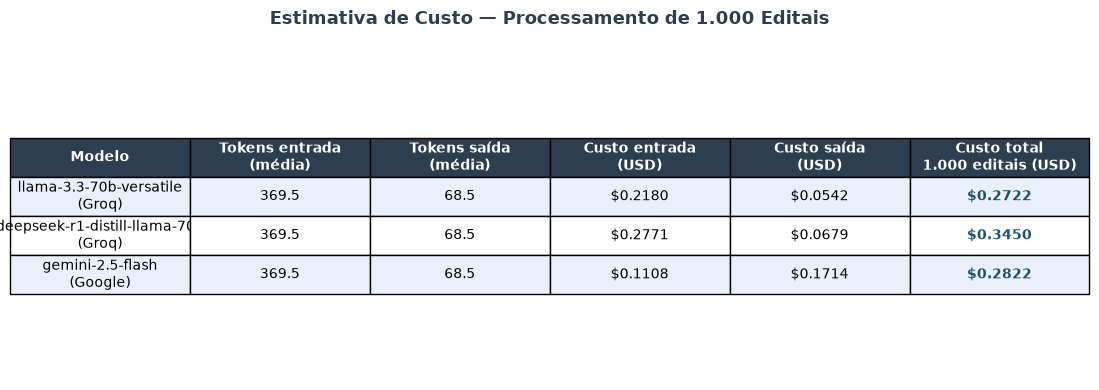

Tabela salva em dados/processed/tabela_custo_modelos.png


In [40]:
# plotando em uma tabela mais bonita

fig, ax = plt.subplots(figsize=(11, 4))
ax.axis("off")

colunas = ["Modelo", "Tokens entrada\n(média)", "Tokens saída\n(média)",
           "Custo entrada\n(USD)", "Custo saída\n(USD)", "Custo total\n1.000 editais (USD)"]

dados = [
    ["llama-3.3-70b-versatile\n(Groq)",          "369.5", "68.5", "$0.2180", "$0.0542", "$0.2722"],
    ["deepseek-r1-distill-llama-70b\n(Groq)",     "369.5", "68.5", "$0.2771", "$0.0679", "$0.3450"],
    ["gemini-2.5-flash\n(Google)",                "369.5", "68.5", "$0.1108", "$0.1714", "$0.2822"],
]

tabela = ax.table(
    cellText=dados,
    colLabels=colunas,
    cellLoc="center",
    loc="center",
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 2.2)

# cabeçalho
for j in range(len(colunas)):
    tabela[0, j].set_facecolor("#2c3e50")
    tabela[0, j].set_text_props(color="white", fontweight="bold")

# linhas alternadas e destaque na última coluna
cores_linhas = ["#eaf0fb", "#ffffff"]
for i in range(1, len(dados) + 1):
    for j in range(len(colunas)):
        tabela[i, j].set_facecolor(cores_linhas[(i - 1) % 2])
        if j == len(colunas) - 1:
            tabela[i, j].set_text_props(fontweight="bold", color="#1a5276")

plt.title("Estimativa de Custo — Processamento de 1.000 Editais",
          fontsize=13, fontweight="bold", pad=20, color="#2c3e50")

plt.tight_layout()
plt.savefig("../dados/processed/tabela_custo_modelos.png", dpi=150, bbox_inches="tight")
plt.show()

print("Tabela salva em dados/processed/tabela_custo_modelos.png")